[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sensioai/blog/blob/master/029_pytorch_datasets/pytorch_datasets.ipynb)

In [1]:
import torch

In [2]:
import os
import json
import numpy as np
import librosa

# Define la ruta del directorio de audios y del archivo JSON de metadatos
audio_dir = "./nsynth/audio" if os.path.exists("./nsynth/audio") else "./nsynth"
json_path = "./nsynth/examples.json"

file_paths = []
labels = []

In [ ]:
if os.path.exists(json_path):
    # Si existe el JSON, lee los metadatos oficiales de NSynth
    with open(json_path, "r") as f:
        metadata = json.load(f)
    for sample_id, info in metadata.items():
        wav_file = os.path.join(audio_dir, f"{sample_id}.wav")
        if os.path.exists(wav_file):
            file_paths.append(wav_file)
            labels.append(info["instrument_family"])
else:

    classes = sorted(os.listdir(audio_dir))
    label_map = {}
    for idx, cls in enumerate(classes):
        cls_folder = os.path.join(audio_dir, cls)
        if os.path.isdir(cls_folder):
            label_map[cls] = idx
            for f in os.listdir(cls_folder):
                if f.endswith((".wav", ".mp3")):
                    file_paths.append(os.path.join(cls_folder, f))
                    labels.append(idx)

In [ ]:
features = []
sr = 16000         
duration = 2.0      
max_len = int(sr * duration)  

In [ ]:
for path in file_paths:

    y, _ = librosa.load(path, sr=sr, duration=duration)
    
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]
        

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    
    mfcc_mean = np.mean(mfcc, axis=1)
    features.append(mfcc_mean)

c:\Users\elmer\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

X = np.array(features, dtype=np.float32)

Y = np.array(labels, dtype=np.int64)


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

X_train = X_train / np.max(X_train) if np.max(X_train) > 0 else X_train
X_test = X_test / np.max(X_test) if np.max(X_test) > 0 else X_test

device = torch.device("cpu")

X_t = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_t = torch.tensor(y_train, dtype=torch.long).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

print(f"Entrenamiento (Train): {X_t.shape[0]} muestras")
print(f"Prueba (Test): {X_test_t.shape[0]} muestras")

Entrenamiento (Train): 3276 muestras
Prueba (Test): 820 muestras


In [9]:
import pandas as pd

df_primeros = pd.DataFrame(X[:20], columns=[f"MFCC_{i+1}" for i in range(40)])
df_primeros["Etiqueta Real"] = Y[:20]

print("Muestra de los primeros 20 datos del dataset (NSynth)")
print(df_primeros.to_string(index=True))

print("Información del dataset de Audio (NSynth)")
print(f"Total de audios procesados (X): {X.shape}")
print(f"Total de etiquetas (Y): {Y.shape}")
print(f"Número de clases de instrumentos (familias): {len(np.unique(Y))}")



Muestra de los primeros 20 datos del dataset (NSynth)
        MFCC_1      MFCC_2      MFCC_3     MFCC_4     MFCC_5     MFCC_6     MFCC_7     MFCC_8     MFCC_9    MFCC_10    MFCC_11    MFCC_12    MFCC_13    MFCC_14    MFCC_15    MFCC_16    MFCC_17    MFCC_18    MFCC_19    MFCC_20    MFCC_21    MFCC_22    MFCC_23    MFCC_24    MFCC_25    MFCC_26    MFCC_27    MFCC_28    MFCC_29    MFCC_30    MFCC_31    MFCC_32    MFCC_33    MFCC_34    MFCC_35    MFCC_36    MFCC_37    MFCC_38    MFCC_39    MFCC_40  Etiqueta Real
0  -475.990784   80.818710   53.487347  35.691288  21.665140   8.415135   1.093080  -2.351573  -6.772385 -11.634976 -14.684932 -16.588804 -16.971321 -14.638849 -11.569644  -9.587252  -9.104780  -9.724385  -9.728904  -9.547460 -10.911127 -12.417590 -11.965827 -10.936348 -11.225188 -11.121512  -9.284259  -8.184788  -9.322162 -10.988998 -12.448548 -14.273865 -15.457094 -15.609053 -15.342794 -14.054433 -13.219518 -13.990488 -12.875748  -7.706225              0
1  -308.805267  243.2889

In [10]:
df_primeros.describe()

,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,MFCC_32,MFCC_33,MFCC_34,MFCC_35,MFCC_36,MFCC_37,MFCC_38,MFCC_39,MFCC_40,Etiqueta Real
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,-388.042664,65.834892,4.264879,12.473999,0.965831,0.749104,-2.947130,-3.274404,-1.338250,0.892525,...,-0.056575,-2.609810,-0.633841,0.342254,-0.207830,-3.647512,-4.283015,-0.977750,-1.392806,3.900000
std,132.254196,62.363438,50.552074,30.531622,24.336096,22.256945,16.643394,16.289755,19.993502,19.727974,...,12.196424,11.767068,12.696849,18.385578,13.198319,11.939442,10.938144,13.576416,11.584595,2.751076
min,-542.282043,-28.887594,-113.508278,-49.481197,-47.370422,-37.666203,-34.198051,-31.213390,-32.788391,-20.985558,...,-16.620531,-27.415447,-21.785418,-26.398611,-20.757105,-31.312302,-21.062128,-18.165363,-20.825750,0.000000
25%,-468.410973,26.253911,-25.242564,-6.249583,-15.475844,-16.880332,-17.385299,-14.169184,-12.279191,-11.213251,...,-8.955480,-6.910621,-7.445633,-11.364054,-7.698206,-8.491884,-12.747139,-9.040551,-8.652909,2.000000
50%,-396.328186,63.918079,-8.133911,11.221126,6.606129,5.078484,-0.322013,-0.957125,-5.252383,-6.838856,...,-3.739233,-3.092300,-3.246656,-3.880805,-3.228701,-2.550492,-3.248722,-2.550596,-2.717830,3.500000
75%,-343.940704,86.276934,34.855427,25.621597,17.796826,12.067855,9.075077,3.985877,0.770047,1.807271,...,7.317298,-1.615758,6.282440,4.977060,8.814660,1.844044,5.666971,0.923487,5.297600,6.000000
max,66.366501,243.288925,115.891869,71.742348,36.196308,50.531998,22.045639,35.226654,41.928520,48.442032,...,28.667112,24.545507,30.473204,44.797848,25.537518,18.548906,13.144630,43.819736,22.395800,9.000000


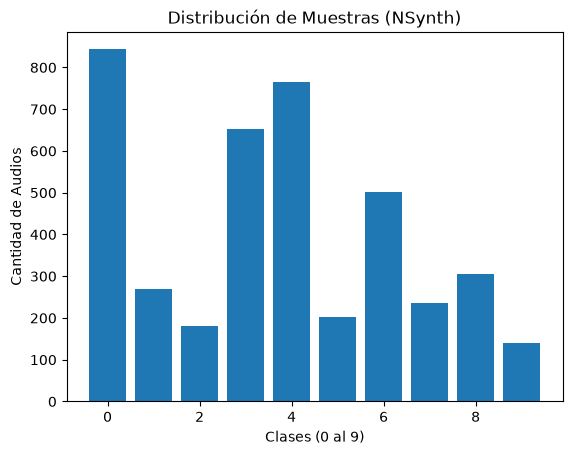

In [11]:
import matplotlib.pyplot as plt
import numpy as np

clases, conteos = np.unique(Y, return_counts=True)

plt.bar(range(10), conteos)
plt.title('Distribución de Muestras (NSynth)')
plt.xlabel('Clases (0 al 9)')
plt.ylabel('Cantidad de Audios')
plt.show()

In [12]:
from sklearn.metrics import accuracy_score
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

def evaluate(x):
    model.eval()
    y_pred = model(x)
    y_probas = softmax(y_pred)
    return torch.argmax(y_probas, axis=1)

In [13]:
D_in = 40
H = 100
D_out = 10

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 150
batch_size = 64
log_each = 5
l = []
model.train()

batches = len(X_t) // batch_size

for e in range(1, epochs + 1):
    _l = []
    for b in range(batches):
        x_b = X_t[b * batch_size : (b + 1) * batch_size]
        y_b = Y_t[b * batch_size : (b + 1) * batch_size]

        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        _l.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    l.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")

y_pred = evaluate(X_test_t)
print("Precisión (Accuracy):", accuracy_score(y_test, y_pred.cpu().numpy()))

Epoch 5/150 Loss 1.99523
Epoch 10/150 Loss 1.84849
Epoch 15/150 Loss 1.75836
Epoch 20/150 Loss 1.69229
Epoch 25/150 Loss 1.63815
Epoch 30/150 Loss 1.59122
Epoch 35/150 Loss 1.54936
Epoch 40/150 Loss 1.51151
Epoch 45/150 Loss 1.47697
Epoch 50/150 Loss 1.44517
Epoch 55/150 Loss 1.41569
Epoch 60/150 Loss 1.38820
Epoch 65/150 Loss 1.36244
Epoch 70/150 Loss 1.33817
Epoch 75/150 Loss 1.31524
Epoch 80/150 Loss 1.29349
Epoch 85/150 Loss 1.27280
Epoch 90/150 Loss 1.25306
Epoch 95/150 Loss 1.23419
Epoch 100/150 Loss 1.21609
Epoch 105/150 Loss 1.19872
Epoch 110/150 Loss 1.18201
Epoch 115/150 Loss 1.16593
Epoch 120/150 Loss 1.15042
Epoch 125/150 Loss 1.13544
Epoch 130/150 Loss 1.12095
Epoch 135/150 Loss 1.10692
Epoch 140/150 Loss 1.09333
Epoch 145/150 Loss 1.08015
Epoch 150/150 Loss 1.06737
Precisión (Accuracy): 0.6609756097560976


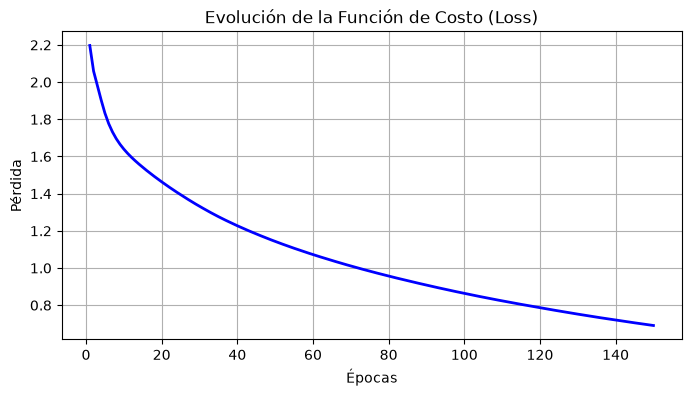

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(l) + 1), l, color='b', linewidth=2)
plt.title("Evolución de la Función de Costo (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.grid(True)
plt.show()

In [15]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred.cpu().numpy())

0.6609756097560976

In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred.cpu().numpy()))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72       169
           1       0.64      0.76      0.69        54
           2       0.91      0.58      0.71        36
           3       0.46      0.66      0.54       131
           4       0.76      0.54      0.63       153
           5       0.37      0.70      0.48        40
           6       0.83      0.69      0.76       101
           7       0.77      0.57      0.66        47
           8       0.95      0.69      0.80        61
           9       0.84      0.75      0.79        28

    accuracy                           0.66       820
   macro avg       0.73      0.67      0.68       820
weighted avg       0.71      0.66      0.67       820



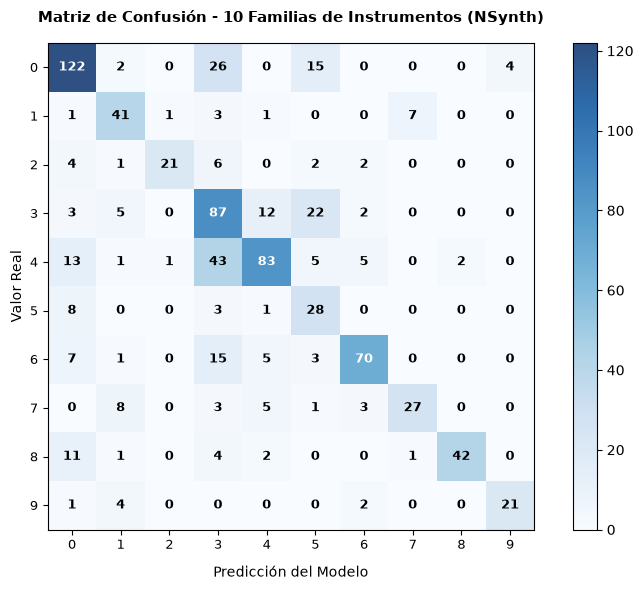

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred_np = evaluate(X_test_t).cpu().numpy()
cm = confusion_matrix(y_test, y_pred_np)

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(cm, cmap='Blues', alpha=0.85)
fig.colorbar(cax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10), fontsize=9)
ax.set_yticklabels(range(10), fontsize=9)

ax.tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)

for i in range(10):
    for j in range(10):
        valor = cm[i, j]
        color_texto = "white" if valor > cm.max() / 2 else "black"
        ax.text(j, i, str(valor), ha='center', va='center', 
                color=color_texto, fontsize=9, fontweight='bold')

plt.title('Matriz de Confusión - 10 Familias de Instrumentos (NSynth)', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Predicción del Modelo', fontsize=10, labelpad=10)
plt.ylabel('Valor Real', fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred.cpu().numpy())
print(cm)

[[122   2   0  26   0  15   0   0   0   4]
 [  1  41   1   3   1   0   0   7   0   0]
 [  4   1  21   6   0   2   2   0   0   0]
 [  3   5   0  87  12  22   2   0   0   0]
 [ 13   1   1  43  83   5   5   0   2   0]
 [  8   0   0   3   1  28   0   0   0   0]
 [  7   1   0  15   5   3  70   0   0   0]
 [  0   8   0   3   5   1   3  27   0   0]
 [ 11   1   0   4   2   0   0   1  42   0]
 [  1   4   0   0   0   0   2   0   0  21]]


In [19]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)

model.eval()
with torch.no_grad():
    train_outputs = model(X_train_t)
    _, train_preds = torch.max(train_outputs, 1)
    train_acc = accuracy_score(y_train, train_preds.cpu().numpy())

print(f"Precisión en Train: {train_acc:.4f}")
print(f"Precisión en Test:  {accuracy_score(y_test, y_pred_np):.4f}")

Precisión en Train: 0.7750
Precisión en Test:  0.6610


In [20]:
from sklearn.metrics import classification_report

y_pred_np = evaluate(X_test_t).cpu().numpy()
print(classification_report(y_test, y_pred_np))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72       169
           1       0.64      0.76      0.69        54
           2       0.91      0.58      0.71        36
           3       0.46      0.66      0.54       131
           4       0.76      0.54      0.63       153
           5       0.37      0.70      0.48        40
           6       0.83      0.69      0.76       101
           7       0.77      0.57      0.66        47
           8       0.95      0.69      0.80        61
           9       0.84      0.75      0.79        28

    accuracy                           0.66       820
   macro avg       0.73      0.67      0.68       820
weighted avg       0.71      0.66      0.67       820



In [21]:
model.eval()
with torch.no_grad():
    y_probas = softmax(model(X_test_t)).cpu().numpy()

In [22]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred_np, average='macro')

0.6792692326843202

In [23]:
from sklearn.metrics import roc_auc_score

auc_macro = roc_auc_score(y_test, y_probas, multi_class='ovr', average='macro')
print(f"ROC AUC Macro: {auc_macro:.4f}")

ROC AUC Macro: 0.9493


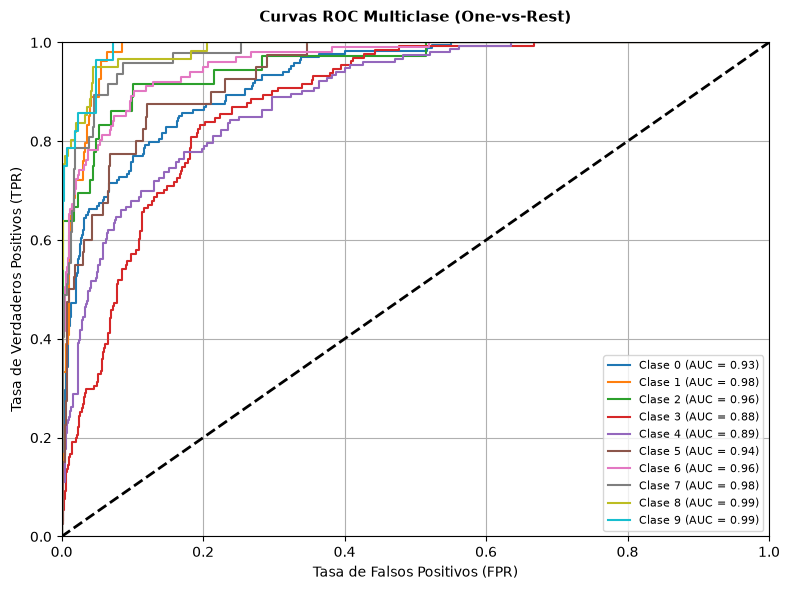

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

model.eval()
with torch.no_grad():
    y_probas = softmax(model(X_test_t)).cpu().numpy()

y_test_bin = label_binarize(y_test, classes=range(10))

plt.figure(figsize=(8, 6))
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probas[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=1.5, label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.axis([0, 1, 0, 1])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=10)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=10)
plt.title('Curvas ROC Multiclase (One-vs-Rest)', fontsize=11, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()